<a href="https://colab.research.google.com/github/smritisitoke/ADITYA-L1-MISSION-DATA-ANALYSIS/blob/main/magnetometer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install netCDF4

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving mag_2026Mar03T065621795.zip to mag_2026Mar03T065621795 (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile("mag_2026Mar03T065621795.zip", 'r') as zip_ref:
    zip_ref.extractall()

print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
import os
print(os.listdir())

['.config', 'L1_MAG91N18P1AL10009209024026061054408180_N00_0000_000803_V00.nc', 'L2_AL1_MAG_20260225_V00.nc', 'mag_2026Mar03T065621795 (1).zip', 'L2_AL1_MAG_20260228_V00.nc', 'L1_MAG91N18P1AL10009009024026060053238330_N00_0000_000802_V00.nc', 'mag_2026Mar03T065621795.zip', 'L1_MAG91N18P1AL10008809024026059055046902_N00_0000_000801_V00.nc', 'L1_MAG91N18P1AL10009309024026061063209184_N00_0000_000803_V00.nc', 'L2_AL1_MAG_20260226_V00.nc', 'L1_MAG91N18P1AL10008909024026059063841671_N00_0000_000801_V00.nc', 'L1_MAG91N18P1AL10009109024026060063526884_N00_0000_000802_V00.nc', 'L2_AL1_MAG_20260227_V00.nc', 'sample_data']


In [ ]:
from netCDF4 import Dataset

file_path = "L2_AL1_MAG_20260227_V00.nc"
data = Dataset(file_path)

print("File opened successfully!")
print(data.variables.keys())

File opened successfully!
dict_keys(['time', 'Bx_gse', 'By_gse', 'Bz_gse', 'Bx_gsm', 'By_gsm', 'Bz_gsm', 'Bx_gse_error', 'By_gse_error', 'Bz_gse_error', 'Bx_gsm_error', 'By_gsm_error', 'Bz_gsm_error', 'Quality_flag_10s_data', 'x_gse', 'y_gse', 'z_gse', 'x_gsm', 'y_gsm', 'z_gsm'])


In [ ]:
import numpy as np

time = data.variables['time'][:]

bx = data.variables['Bx_gse'][:]
by = data.variables['By_gse'][:]
bz = data.variables['Bz_gse'][:]

print("Extraction complete")
print("Total points:", len(time))

Extraction complete
Total points: 8640


In [ ]:
print("Bx min:", np.min(bx))
print("Bx max:", np.max(bx))

print("By min:", np.min(by))
print("By max:", np.max(by))

print("Bz min:", np.min(bz))
print("Bz max:", np.max(bz))

Bx min: -17.979097
Bx max: -5.9171863
By min: -8.054209
By max: 0.997399
Bz min: -2.6195338
Bz max: 7.109998


In [ ]:
quality = data.variables['Quality_flag_10s_data'][:]

good_mask = (quality == 0)

bx_good = bx[good_mask]
by_good = by[good_mask]
bz_good = bz[good_mask]
time_good = time[good_mask]

print("Good data points:", len(bx_good))

Good data points: 0


In [ ]:
B_total = np.sqrt(bx**2 + by**2 + bz**2)

print("Mean |B|:", np.mean(B_total))
print("Max |B|:", np.max(B_total))
print("Min |B|:", np.min(B_total))

Mean |B|: 11.548105889713067
Max |B|: 18.925449622813012
Min |B|: 6.679709598211387


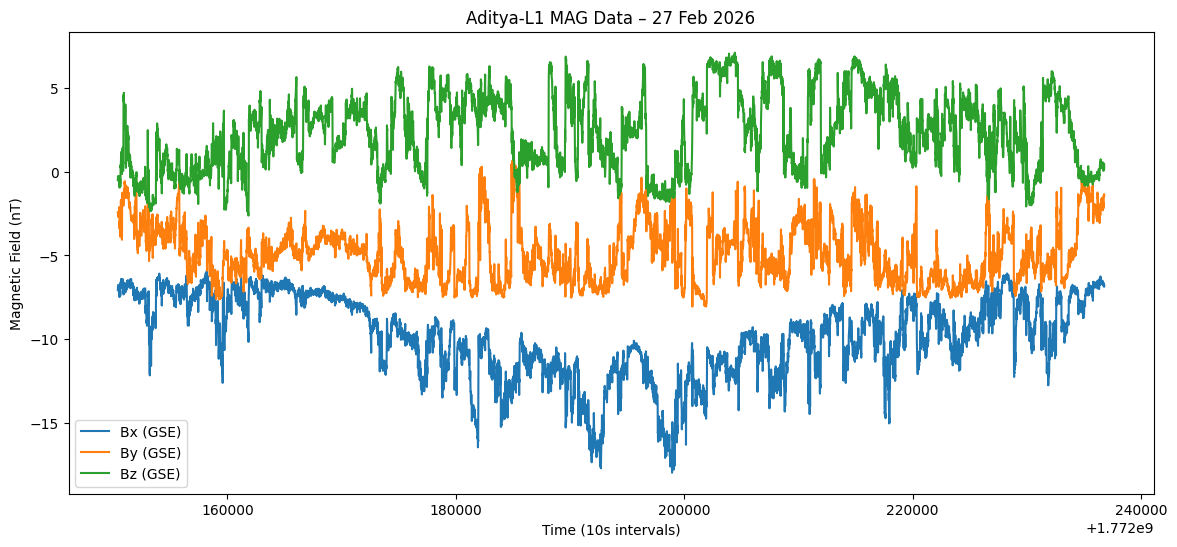

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(time, bx, label='Bx (GSE)')
plt.plot(time, by, label='By (GSE)')
plt.plot(time, bz, label='Bz (GSE)')

plt.xlabel("Time (10s intervals)")
plt.ylabel("Magnetic Field (nT)")
plt.title("Aditya-L1 MAG Data – 27 Feb 2026")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

time_utc = pd.to_datetime(time, unit='s')

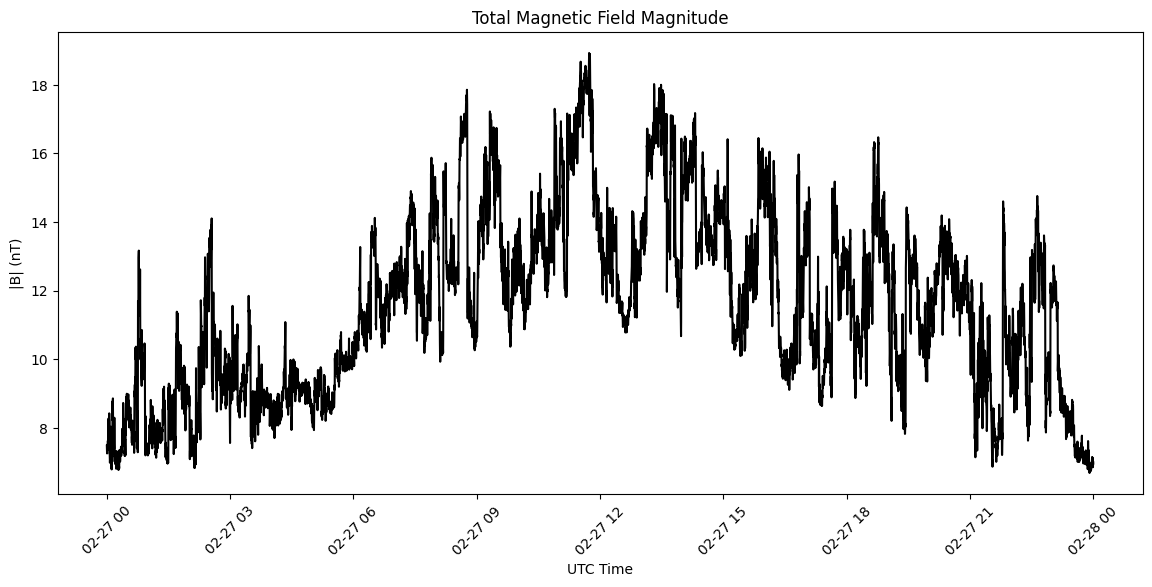

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(time_utc, B_total, color='black')

plt.xlabel("UTC Time")
plt.ylabel("|B| (nT)")
plt.title("Total Magnetic Field Magnitude")

plt.xticks(rotation=45)
plt.show()

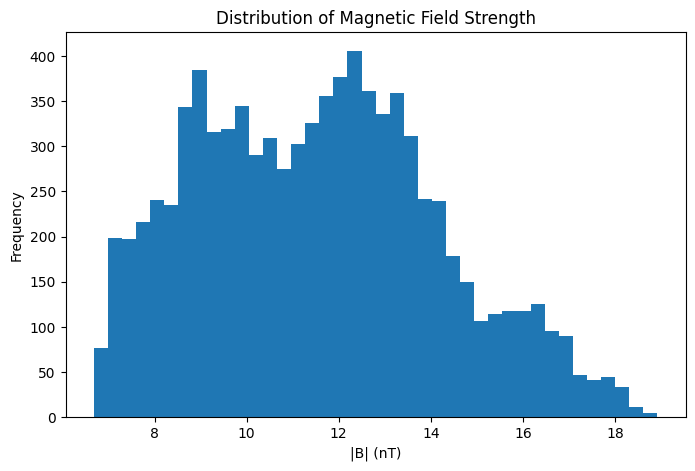

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(B_total, bins=40)

plt.xlabel("|B| (nT)")
plt.ylabel("Frequency")
plt.title("Distribution of Magnetic Field Strength")
plt.show()

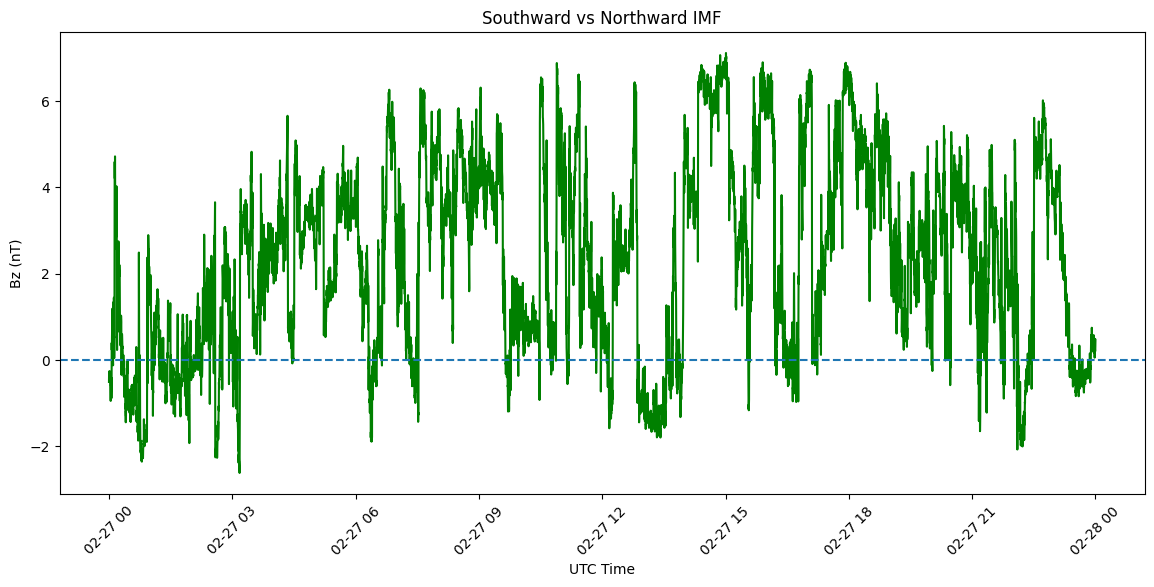

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(time_utc, bz, color='green')

plt.axhline(0, linestyle='--')

plt.xlabel("UTC Time")
plt.ylabel("Bz (nT)")
plt.title("Southward vs Northward IMF")
plt.xticks(rotation=45)
plt.show()

NameError: name 'threshold' is not defined

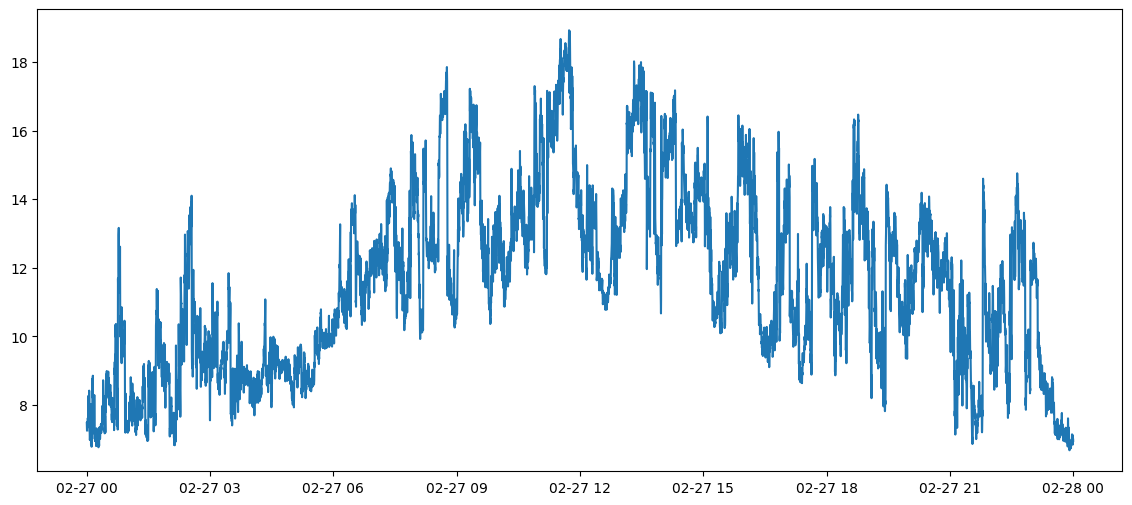

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(time_utc, B_total, label="|B|")

plt.axhline(threshold, linestyle='--', label="Disturbance Threshold")

plt.xlabel("UTC Time")
plt.ylabel("|B| (nT)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

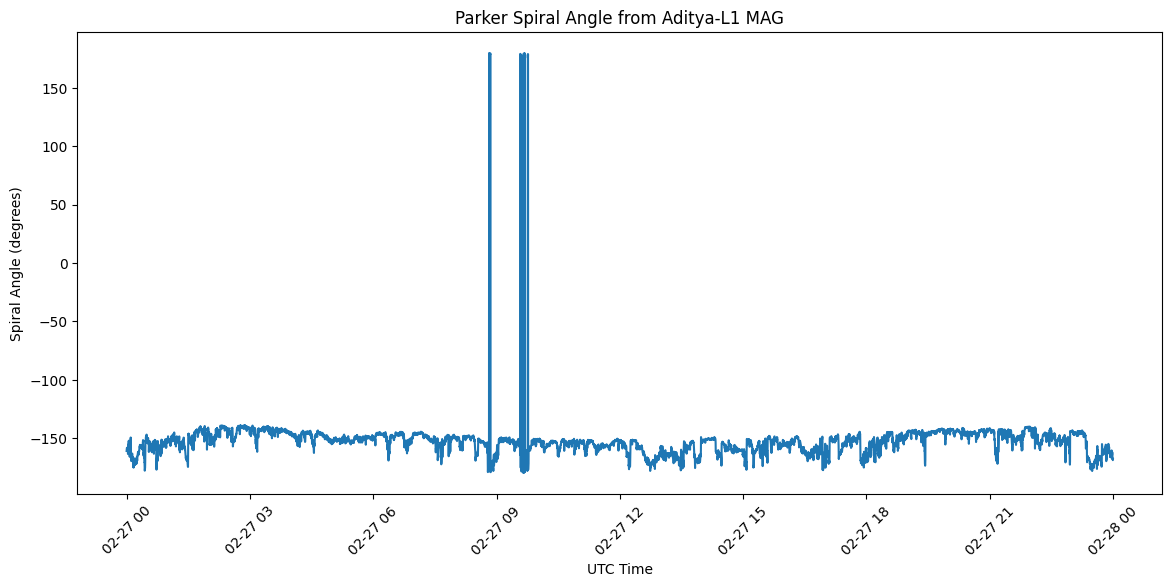

In [ ]:
import numpy as np

# Parker spiral angle
theta = np.degrees(np.arctan2(by, bx))

plt.figure(figsize=(14,6))
plt.plot(time_utc, theta)

plt.xlabel("UTC Time")
plt.ylabel("Spiral Angle (degrees)")
plt.title("Parker Spiral Angle from Aditya-L1 MAG")
plt.xticks(rotation=45)
plt.show()

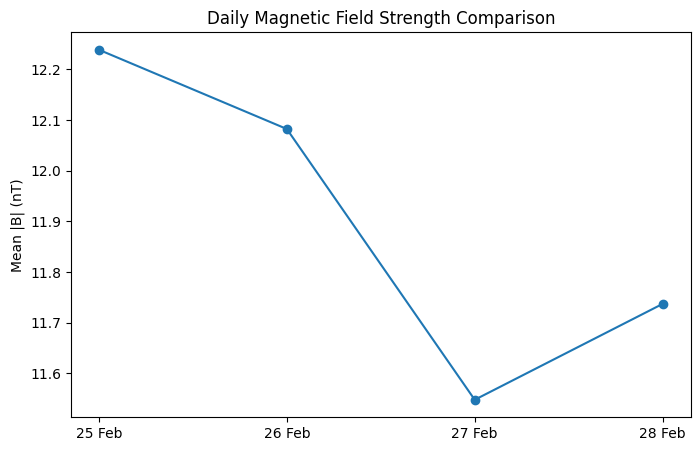

In [ ]:
files = [
"L2_AL1_MAG_20260225_V00.nc",
"L2_AL1_MAG_20260226_V00.nc",
"L2_AL1_MAG_20260227_V00.nc",
"L2_AL1_MAG_20260228_V00.nc"
]

means = []

for f in files:
    d = Dataset(f)
    bx = d.variables['Bx_gse'][:]
    by = d.variables['By_gse'][:]
    bz = d.variables['Bz_gse'][:]

    B = np.sqrt(bx**2 + by**2 + bz**2)
    means.append(np.mean(B))

plt.figure(figsize=(8,5))
plt.plot(["25 Feb","26 Feb","27 Feb","28 Feb"], means, marker='o')

plt.ylabel("Mean |B| (nT)")
plt.title("Daily Magnetic Field Strength Comparison")
plt.show()

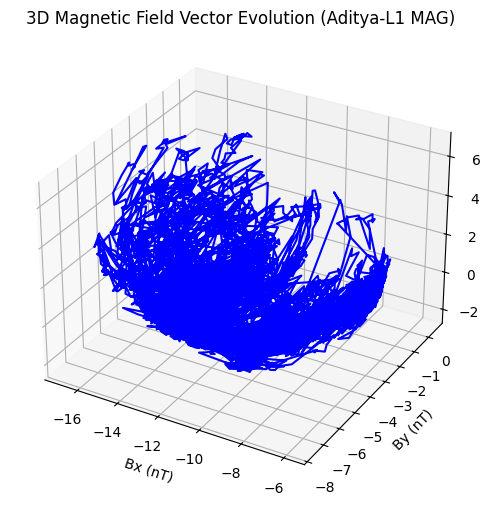

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(bx, by, bz, color='blue')

ax.set_xlabel("Bx (nT)")
ax.set_ylabel("By (nT)")
ax.set_zlabel("Bz (nT)")

ax.set_title("3D Magnetic Field Vector Evolution (Aditya-L1 MAG)")

plt.show()

In [ ]:
import numpy as np

print("Standard Deviation Bx:", np.std(bx))
print("Standard Deviation By:", np.std(by))
print("Standard Deviation Bz:", np.std(bz))
print("Standard Deviation |B|:", np.std(B_total))

Standard Deviation Bx: 2.3962104
Standard Deviation By: 1.7709725
Standard Deviation Bz: 2.0616133
Standard Deviation |B|: 2.630225726913251


In [ ]:
import pandas as pd

# Convert Unix epoch time to datetime
time_utc = pd.to_datetime(time, unit='s')

print("Start time:", time_utc[0])
print("End time:", time_utc[-1])

Start time: 2026-02-27 00:00:00
End time: 2026-02-27 23:59:50


In [ ]:
threshold = np.mean(B_total) + 2*np.std(B_total)

disturbance_indices = np.where(B_total > threshold)[0]

print("Disturbance threshold:", threshold)
print("Number of disturbance points:", len(disturbance_indices))

Disturbance threshold: 16.80855734353957
Number of disturbance points: 265


In [ ]:
file_path2 = "L2_AL1_MAG_20260226_V00.nc"
data2 = Dataset(file_path2)

bx2 = data2.variables['Bx_gse'][:]
by2 = data2.variables['By_gse'][:]
bz2 = data2.variables['Bz_gse'][:]

B_total2 = np.sqrt(bx2**2 + by2**2 + bz2**2)

print("Mean |B| (26 Feb):", np.mean(B_total2))

Mean |B| (26 Feb): 12.08248402509776


In [ ]:
print("Mean Magnetic Field:", np.mean(B_total))
print("Standard Deviation:", np.std(B_total))

print("Solar wind conditions: Moderate variability (~2–3 nT fluctuations).")
print("No sustained strong southward Bz detected → No major geomagnetic storm.")

Mean Magnetic Field: 11.548105889713067
Standard Deviation: 2.630225726913251
Solar wind conditions: Moderate variability (~2–3 nT fluctuations).
No sustained strong southward Bz detected → No major geomagnetic storm.


In [ ]:
print("What numbers are in quality?", np.unique(quality))


What numbers are in quality? [1.]


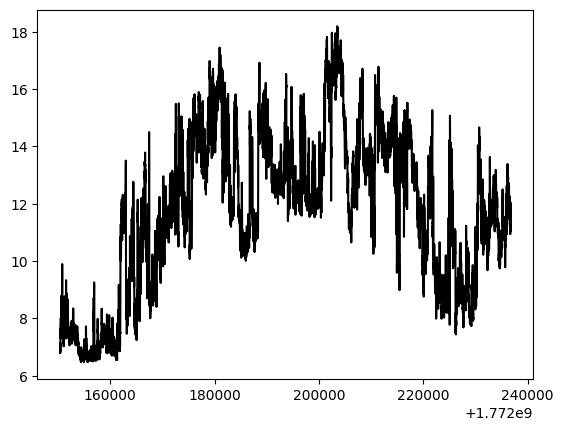

In [ ]:
Btotal = np.sqrt(bx**2 + by**2 + bz**2)  # Total strength
plt.plot(time, Btotal, 'k-')  # Black line


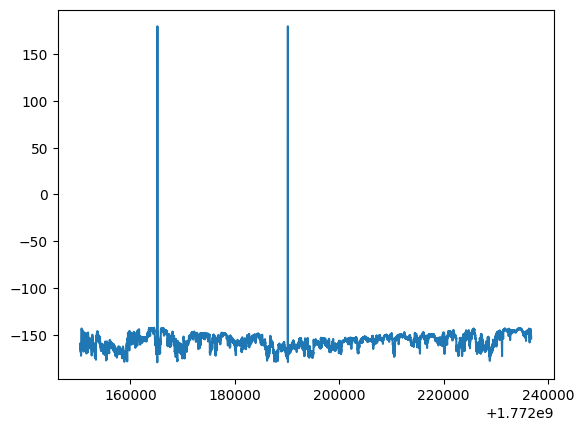

In [ ]:
angle = np.arctan2(by, bx) * 180/3.14  # Wind direction
plt.plot(time, angle)
